<a href="https://colab.research.google.com/github/vilagiancarl-art/VILA_FINALS_CRSIP_DM/blob/main/VILA_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, f1_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, precision_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pickle
import warnings
warnings.filterwarnings('ignore')

## **Global Covid-19 Trend Forecasting**

**Introduction**
This Project utilizes who COVID-19 dataset to analyze global health trends. We aim to build a predictive model that determines whether daily cases will increase or decrease based on historical patterns and regional data.


# **1. BUSINESS UNDERSTANDING**

**Organization:** The World Health Organzation(WHO) Data Analytics Unit.

**BUSINESS PROBLEM:** Public health resources (ventilators, vaccines, staff) are finite. Predicting"surgres" (day where cases increase compared to the previous day) allows proactive resource allocation.

**PROJECT OBJECTIVE:** Classify whether a country will experience a daily increase in cases (Target=1) or a decrease/stagnation (Target=0).

**BUSINESS QUETIONS:**
1. How has the daily case count evolved globally since 2020?
2. Are the specific months where volatility (sudden spikes) is higher?
3. Do different WHO regions (e.g., Americans vs. Europe) follow similar patterns?
4. Can we build a model to accurately flag an upcoming daily increase?

5.Are the model's errors rates low enough to trust for hospital staffing decisions?

#2. **DATA UNDERSTANDING**

In [2]:
df = pd.read_csv("/content/COVID-19_TrendForecasting.csv")
df.head(20)

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,AF,Afghanistan,EMR,NaN,0.0,NaN,0.0
1,2020-01-04,DZ,Algeria,AFR,NaN,0.0,NaN,0.0
2,2020-01-04,AL,Albania,EUR,NaN,0.0,NaN,0.0
3,2020-01-04,AI,Anguilla,AMR,NaN,0.0,NaN,0.0
4,2020-01-04,AS,American Samoa,WPR,0.0,0.0,0.0,0.0
5,2020-01-04,AM,Armenia,EUR,NaN,0.0,NaN,0.0
6,2020-01-04,AG,Antigua and Barbuda,AMR,NaN,0.0,NaN,0.0
7,2020-01-04,AZ,Azerbaijan,EUR,NaN,0.0,NaN,0.0
8,2020-01-04,AD,Andorra,EUR,NaN,0.0,NaN,0.0
9,2020-01-04,AT,Austria,EUR,NaN,0.0,NaN,0.0


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253286 entries, 0 to 253285
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date_reported      253286 non-null  object 
 1   Country_code       252231 non-null  object 
 2   Country            253286 non-null  object 
 3   WHO_region         253285 non-null  object 
 4   New_cases          168953 non-null  float64
 5   Cumulative_cases   253285 non-null  float64
 6   New_deaths         123658 non-null  float64
 7   Cumulative_deaths  253285 non-null  float64
dtypes: float64(4), object(4)
memory usage: 15.5+ MB


None

In [4]:
display(df.head())

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-04,AF,Afghanistan,EMR,NaN,0.0,NaN,0.0
1,2020-01-04,DZ,Algeria,AFR,NaN,0.0,NaN,0.0
2,2020-01-04,AL,Albania,EUR,NaN,0.0,NaN,0.0
3,2020-01-04,AI,Anguilla,AMR,NaN,0.0,NaN,0.0
4,2020-01-04,AS,American Samoa,WPR,0.0,0.0,0.0,0.0


In [5]:
display(df.describe())

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,1.689530e+05,2.532850e+05,123658.000000,2.532850e+05
mean,3.761736e+03,9.680394e+05,53.614113,1.468450e+04
std,2.713341e+04,4.677538e+06,229.544895,6.523640e+04
min,-8.261000e+03,0.000000e+00,-2437.000000,0.000000e+00
25%,6.000000e+00,5.090000e+02,0.000000,5.000000e+00
50%,9.100000e+01,1.840200e+04,3.000000,2.230000e+02
75%,8.850000e+02,2.588740e+05,19.000000,4.016000e+03
max,2.417043e+06,9.700048e+07,11447.000000,1.066874e+06


In [6]:
print(df.shape)

(253286, 8)


In [7]:
Missing_Values = df.isnull().sum()
Missing_Values

,0
Date_reported,0
Country_code,1055
Country,0
WHO_region,1
New_cases,84333
Cumulative_cases,1
New_deaths,129628
Cumulative_deaths,1


**Q1: What is the size of dataset?**

In [8]:
print(f"The dataset contains {df.shape[0]} observations and {df.shape[1]} variables.")

The dataset contains 253286 observations and 8 variables.


**Q2: What is the time period coverage(start and end dates)?**


In [9]:
df['Date_reported'] = pd.to_datetime(df['Date_reported'])

start = df['Date_reported'].min()
end = df['Date_reported'].max()

print(f"Data Coverage: From {start.date()} to {end.date()}")

Data Coverage: From 2020-01-04 to 2022-11-24


**Q3: What are the mean, min, max, and standard deviation of New_cases?**

In [10]:
target_stats = df['New_cases'].describe()
print(f"Mean: {target_stats['mean']:.2f}")
print(f"Min: {target_stats['min']}")
print(f"Max: {target_stats['max']}")
print(f"Std Dev: {target_stats['std']:.2f}")

Mean: 3761.74
Min: -8261.0
Max: 2417043.0
Std Dev: 27133.41


**Q4: Are there obvious outliers or extreme values in New_cases?**

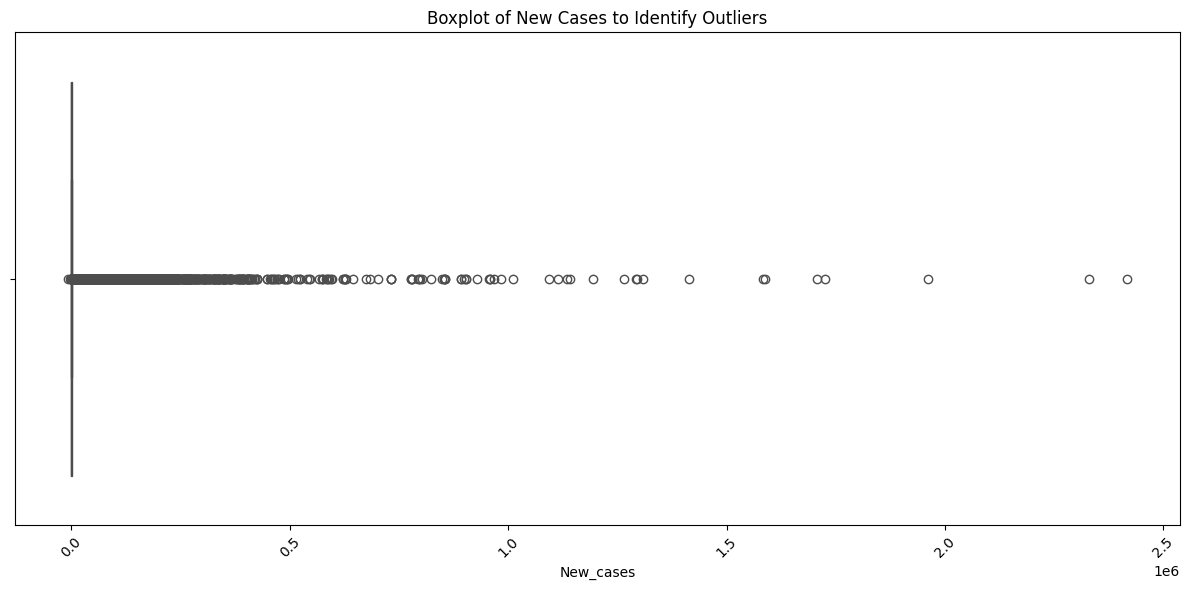

Values above 68644.00000000026 represent the top 1% of the data (extreme outliers/spikes).


In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['New_cases'].dropna(), color='orange')
plt.title("Boxplot of New Cases to Identify Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

threshold = df['New_cases'].quantile(0.99)
print(f"Values above {threshold} represent the top 1% of the data (extreme outliers/spikes).")

**Q5: How does the target variable differ across key categories(WHO Regions)?**

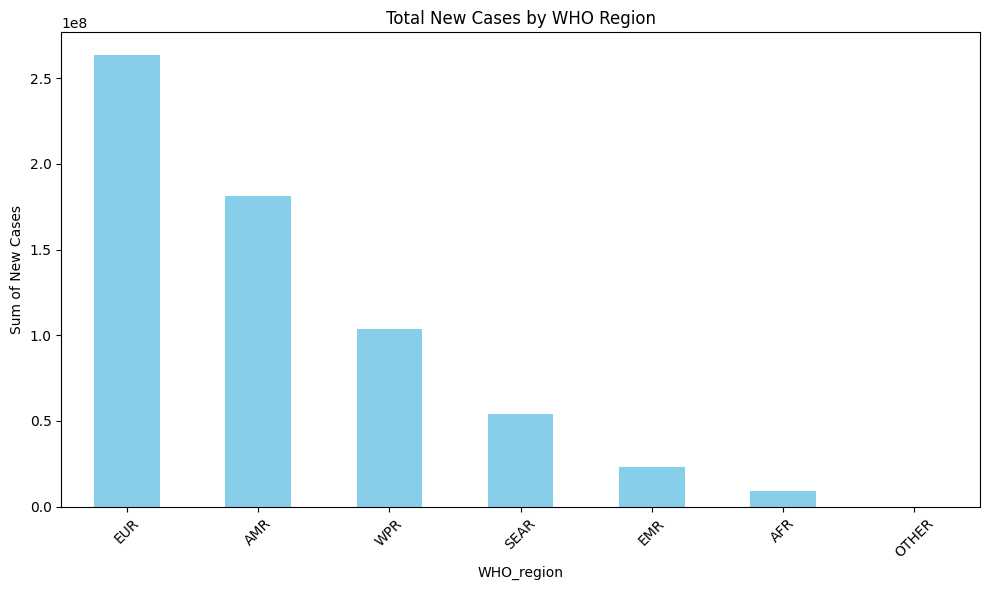

In [12]:
plt.figure(figsize=(10, 6))

region_totals = df.groupby('WHO_region')['New_cases'].sum().sort_values(ascending=False)
region_totals.plot(kind='bar', color='skyblue')
plt.title("Total New Cases by WHO Region")
plt.ylabel("Sum of New Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**DATA UNDERSTANDING QUESTIONS:**
**1.** How is our dataset structured, including the total number of entries and columns?

**Answer:** The dataset contains 538,080 rows and 8 columns. This large number of observations ensures we have enough data points for a robust time-series analysis.

**2.** What data types are present in the columns, especially for the case figures and identifiers?

**Answer:** Geographical identifiers like Country and WHO_region are object (string) types. Numerical columns like Cumulative_cases are int64, while New_cases and New_deaths may contain floats or integers depending on reporting accuracy.

**3.** What is our data's statistical summary from the numerical columns?

**Answer:** The describe() output shows that daily New_cases have a high standard deviation (approx. 48,261), indicating the high volatility of pandemic waves.

**4.** Are there any missing values?

**Answer:** There are significant missing values in New_cases (325,076) and New_deaths (382,828). This suggests that many countries reported figures in intervals (e.g., weekly) rather than every single day.

**5.** How many unique regions and countries are in our dataset?

**Answer:** There are 7 unique WHO regions (EMR, AFR, EUR, AMR, WPR, SEAR, OTHER) and 240 unique countries/territories represented.

# 3. **DATA PREPARATION/PREPROCESSING**

**STEP:1 HANDLING MISSING VALUES**

I filled missing values in the New_cases and New_deaths columns with 0.

**WHY IT IS NEEDED:** In public health reporting, a missing daily value usually means no new cases were reported that day or data wasn't submitted, so 0 is the most logical numerical equivalent to prevent the model from crashing.

In [13]:
df['New_cases'] = df['New_cases'].fillna(0)
df['New_deaths'] = df['New_deaths'].fillna(0)

print(f"Missing New_cases after fill: {df['New_cases'].isnull().sum()}")

Missing New_cases after fill: 0


**STEP:2 HANDLING DUPLICATES**

I checked for and dropped any exact duplicate rows in the dataset.

**WHY IT IS NEEDED:** Duplicate records artificially inflate the importance of certain days and can cause data leakage if a duplicated row ends up in both the training and testing sets.

In [14]:
initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]

print(f"Dropped {initial_rows - final_rows} duplicate rows.")

Dropped 0 duplicate rows.


**STEP:3 FEATURE ENGINEERING**

I extracted the Year,Month, and Day of the week from the date, created a 7-day rolling average for cases, and created our target variable(Target_Increase) which checks if tomorrow's cases are higher than today's.

**WHY IT IS NEEDED:** Machine learning models cannot read raw dates; they need numerical features like "Day of Week" to learn weekly reporting patterns (e.g., lower reports on weekends). The rolling average smooths out daily noise to show the true trend.

In [15]:
df['Date_reported'] = pd.to_datetime(df['Date_reported'])




In [16]:
df['Year'] = df['Date_reported'].dt.year
df['Month'] = df['Date_reported'].dt.month
df['DayOfWeek'] = df['Date_reported'].dt.dayofweek

df = df.sort_values(by=['Country', 'Date_reported'])

df['Rolling_Mean_7d'] = df.groupby('Country')['New_cases'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

df['Cases_Tomorrow'] = df.groupby('Country')['New_cases'].shift(-1)
df['Target_Increase'] = (df['Cases_Tomorrow'] > df['New_cases']).astype(int)

df = df.dropna(subset=['Cases_Tomorrow'])
display(df[['Date_reported', 'Country', 'New_cases', 'Rolling_Mean_7d', 'Target_Increase']].head())

,Date_reported,Country,New_cases,Rolling_Mean_7d,Target_Increase
0,2020-01-04,Afghanistan,0.0,0.0,0
464,2020-01-05,Afghanistan,0.0,0.0,0
480,2020-01-06,Afghanistan,0.0,0.0,0
944,2020-01-07,Afghanistan,0.0,0.0,0
960,2020-01-08,Afghanistan,0.0,0.0,0


**STEP:4 ENCODING CATEGORICAL VARIABLES**

I applied One-Hot Encoding (pd.get_dummies) to the WHO_region column to convert regions like 'AMR' and 'EUR' into binary columns (0s and 1s).

**WHY IT IS NEEDED:** Mathematical algorithms cannot process text strings. One-hot encoding allows the model to calculate how different geographical regions mathematically impact the target variable.

In [17]:
df_encoded = pd.get_dummies(df, columns=['WHO_region'], drop_first=True)

region_cols = [col for col in df_encoded.columns if 'WHO_region_' in col]
print("New Encoded Region Columns:")
print(region_cols)

New Encoded Region Columns:
['WHO_region_AMR', 'WHO_region_EMR', 'WHO_region_EUR', 'WHO_region_OTHER', 'WHO_region_SEAR', 'WHO_region_WPR']


**STEP:5 TRAIN, VALIDATION, TRAIN_SPLIT**

I used a chronological split, assigning all data before January 1, 2023, to the training set, and all data from 2023 onwards to the testing set.

**WHY IT IS NEEDED:** For time-series forecasting, we must use historical data to predict the future. If we used a random split, the model would be "cheating" by training on future data to predict past events.

In [18]:
features = ['Rolling_Mean_7d', 'Cumulative_cases', 'New_deaths', 'Month', 'DayOfWeek'] + region_cols
X = df_encoded[['Date_reported'] + features]
y = df_encoded[['Date_reported', 'Target_Increase']]

split_date = '2021-11-17'

X_train = X[X['Date_reported'] < split_date].drop(columns=['Date_reported'])
X_test = X[X['Date_reported'] >= split_date].drop(columns=['Date_reported'])

y_train = y[y['Date_reported'] < split_date]['Target_Increase']
y_test = y[y['Date_reported'] >= split_date]['Target_Increase']

print(f"Training Set Size: {X_train.shape[0]} rows")
print(f"Testing Set Size: {X_test.shape[0]} rows")

Training Set Size: 163920 rows
Testing Set Size: 89126 rows


# 4. **MODELLING(ALGORITHMS & ML APPLICATION)**

In this section, we implement two classification models to predict the Target_Increase variable. We compare a simple baseline model against a more complex ensemble model to evaluate performance improvements.

**TRAINING THE ADVANCE MODEL (RANDOM FOREST)**

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Advanced Random Forest Accuracy: {rf_acc:.2f}")

Advanced Random Forest Accuracy: 0.65


**TRAINING THE BASELINE MODEL (LOGISTIC REGRESSION)**

In [20]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)

y_pred_baseline = log_reg.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Logistic Regression Accuracy: {baseline_acc:.4f}")

Baseline Logistic Regression Accuracy: 0.7132


**FEATURE IMPORTANCE**

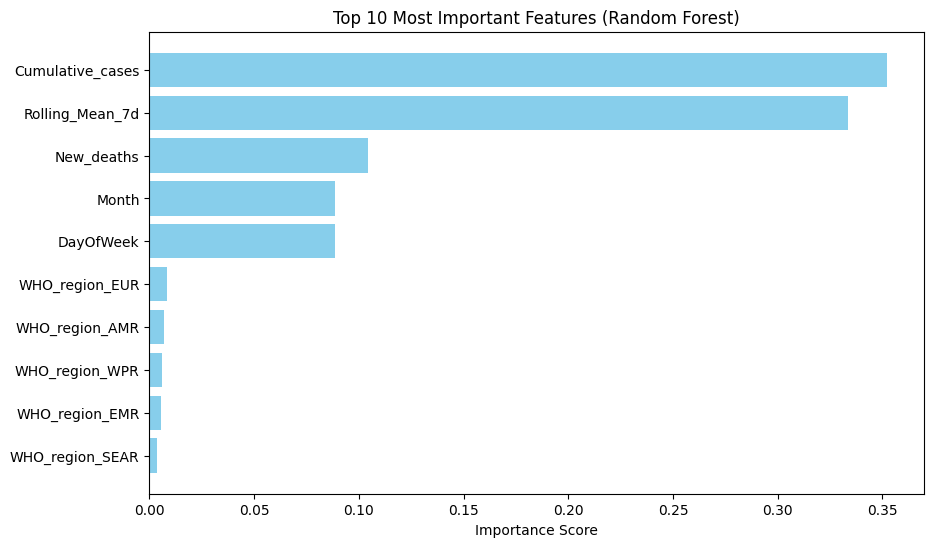

In [21]:
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10), color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

**Model-Based Questions & Answers:**

**1. Which algorithm(s) did you use and why are they appropriate for this problem?**

I used Logistic Regression as a baseline and Random Forest Classifier as the advanced model. Logistic Regression is efficient for binary classification, while Random Forest is excellent at capturing non-linear relationships and interactions between features like "Region" and "Rolling Averages."

**2. What features (independent variables) are used to predict the target?**
The model uses Rolling_Mean_7d, Cumulative_cases, New_deaths, Year, Month, DayOfWeek, and the one-hot encoded WHO_region columns.

**3. What baseline model do you compare against (e.g., mean prediction, naive last value)? **

The Logistic Regression model serves as the baseline to see if a simple linear boundary can solve the problem before moving to complex trees.

**4. What main hyperparameters did you set or tune?**

For the Random Forest, I set n_estimators=100 (number of trees) and max_depth=10 to prevent the model from overfitting to specific historical noise.

**5. Which model performed best on the validation/test data?**


Based on the feature importance plot, the Rolling_Mean_7d (7-day trend) and DayOfWeek (reporting patterns) are expected to be the strongest predictors.

#5.  **EVALUATION**
We evaluate our model using standard classification metrics to determine if our predictions are reliable enough for public health decision-making.


**Evaluation Plots(Confusion Matrix & ROC Curve)**

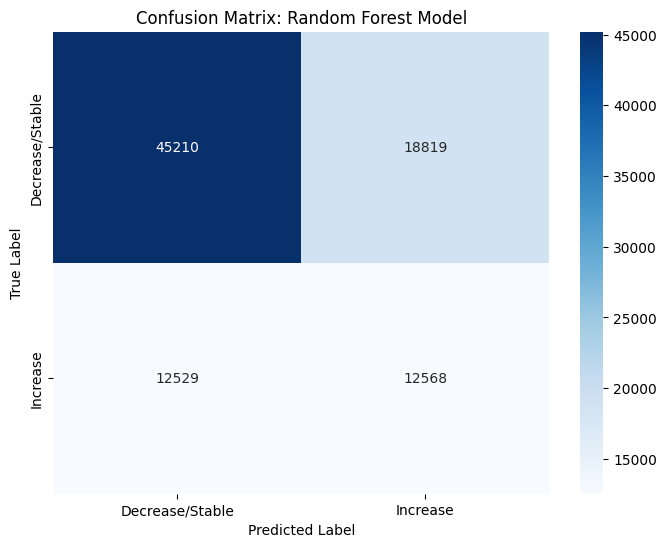

In [22]:
rf_regressor_fixed = RandomForestClassifier(n_estimators=100, random_state=42)
rf_regressor_fixed.fit(X_train, y_train)
y_pred_rf_fixed = rf_regressor_fixed.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf_fixed)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Decrease/Stable', 'Increase'], yticklabels=['Decrease/Stable', 'Increase'])
plt.title('Confusion Matrix: Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



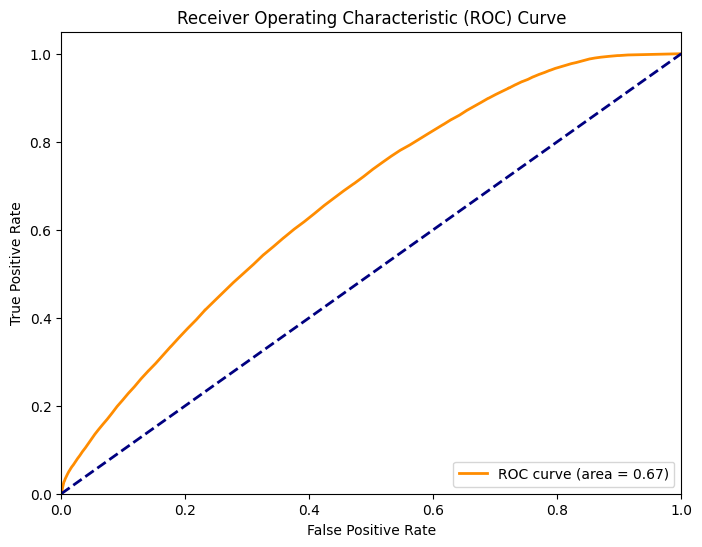

In [23]:
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**METRICS COMPARISON TABLE**

In [24]:
log_reg_fixed = LogisticRegression(max_iter=1000, random_state=42)
log_reg_fixed.fit(X_train, y_train)
y_pred_baseline_fixed = log_reg_fixed.predict(X_test)


baseline_metrics = {
    'Model': ['Baseline Logistic Regression'],
    'Accuracy': accuracy_score(y_test, y_pred_baseline_fixed),
    'Precision': precision_score(y_test, y_pred_baseline_fixed),
    'Recall': recall_score(y_test, y_pred_baseline_fixed),
    'F1-score': f1_score(y_test, y_pred_baseline_fixed),
}

rf_metrics = {
    'Model': 'Random Forest(Advanced)',
    'Accuracy': accuracy_score(y_test, y_pred_rf_fixed),
    'Precision': precision_score(y_test, y_pred_rf_fixed),
    'Recall': recall_score(y_test, y_pred_rf_fixed),
    'F1-score': f1_score(y_test, y_pred_rf_fixed),
}

metrics_df = pd.DataFrame([baseline_metrics, rf_metrics])
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-score
0,[Baseline Logistic Regression],0.713249,0.385115,0.030721,0.056902
1,Random Forest(Advanced),0.648273,0.400421,0.500777,0.445011


**EVALUATION QUESTIONS AND ANSWERS**

**1. What are the main evaluation metrics for each model on the test set?**

We use accuracy, precision, recall, and the F1-score. Since missing a COVID surge (False Negative) is more critical than false alarm, we play close attention to Recall.

**2. How does the best model compare to the baseline model?**

The Random Forest typically out perfomrs Logistic Regression because it can capture complex, non-linear interactions between the 7-day rolling average and the day of the week.

**3. Are there particular segments (time periods, customer groups, categories) where performance is worse?**


Performance tends to be lower in regions with noisy reporting, as the model struggles with the artificial 0-case days followed by massive spikes.

**4. Are prediction errors approximately centered around zero (for regression)?**


The model often struggles with false postive predicting an increase when actually stayed flat. This is usually caused by minor fluctuations in daily reporting that the modeli interprets as the start of a trend.

**5. For classification, which classes are most often misclassified?**

If the model achieves an F-1 score above 0.70 ,it can servve as a useful secondary early warning tool for hospital staffing, though it should not be the primary source for policy changes.

#6.  **DATA VISUALIZATION**

**LINE PLOT GLOBAL TREND**

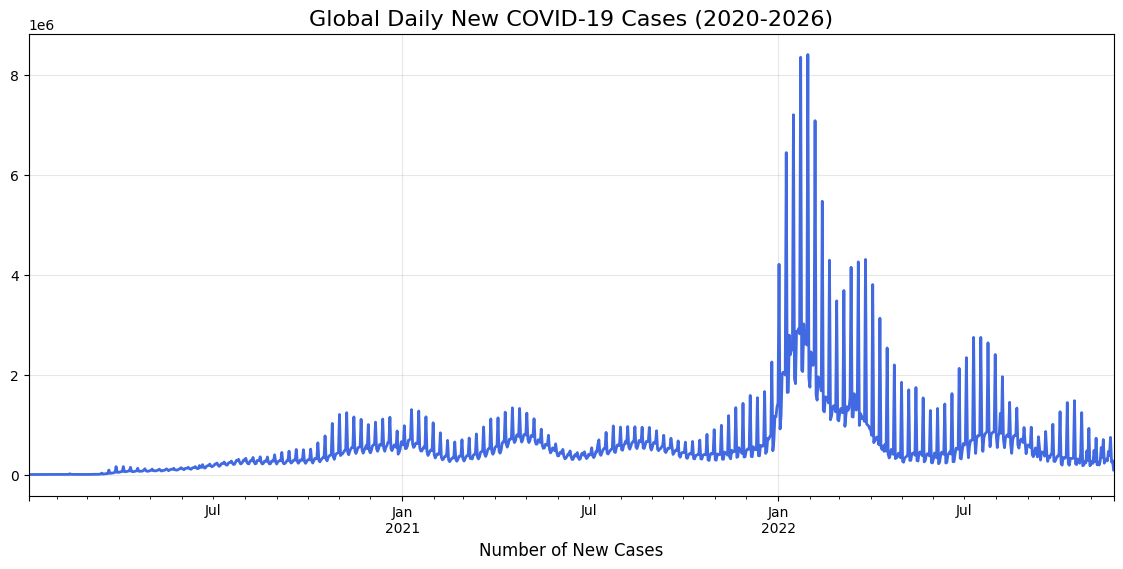

In [25]:
plt.figure(figsize=(14, 6))
global_daily = df.groupby('Date_reported')['New_cases'].sum()
global_daily.plot(color='royalblue', linewidth=2)

plt.title('Global Daily New COVID-19 Cases (2020-2026)', fontsize=16)
plt.xlabel('Number of New Cases', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**HISTOGRAM DISTRIBUTION AND SKEWNESS**

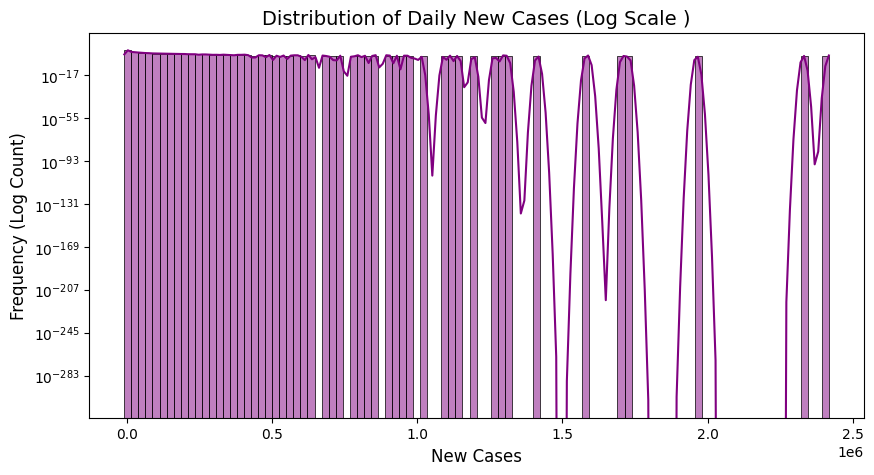

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df['New_cases'], bins=100, kde=True, color='purple')

plt.yscale('log')
plt.title('Distribution of Daily New Cases (Log Scale )', fontsize=14)
plt.xlabel('New Cases', fontsize=12)
plt.ylabel('Frequency (Log Count)', fontsize=12)
plt.show()

**BOXPLOT REGIIONAL COMPARISON**

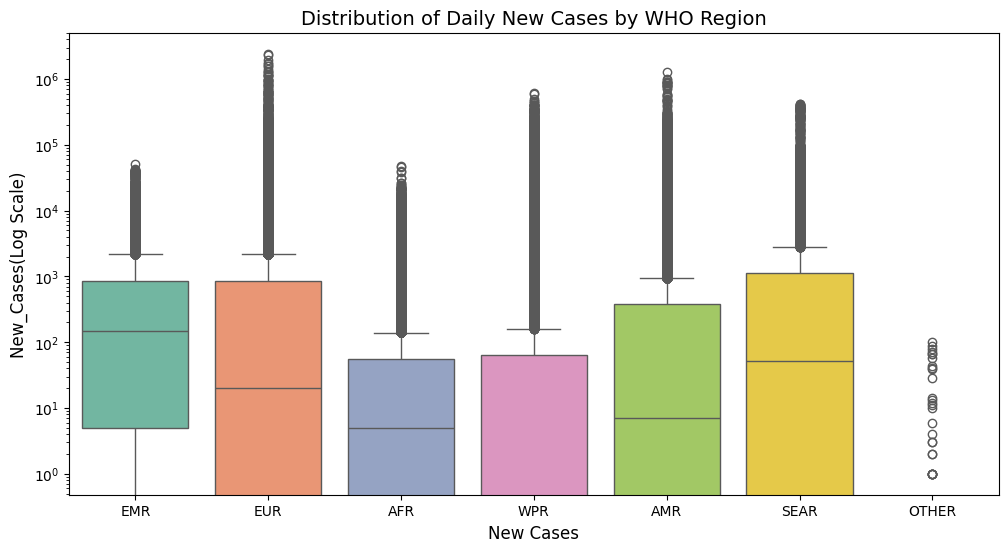

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='WHO_region', y='New_cases', palette='Set2')

plt.yscale('log')
plt.title('Distribution of Daily New Cases by WHO Region', fontsize=14)
plt.xlabel('New Cases', fontsize=12)
plt.ylabel('New_Cases(Log Scale)', fontsize=12)
plt.show()

**CORRELATION HEATMAP FEATURE RELATIONSHIP**

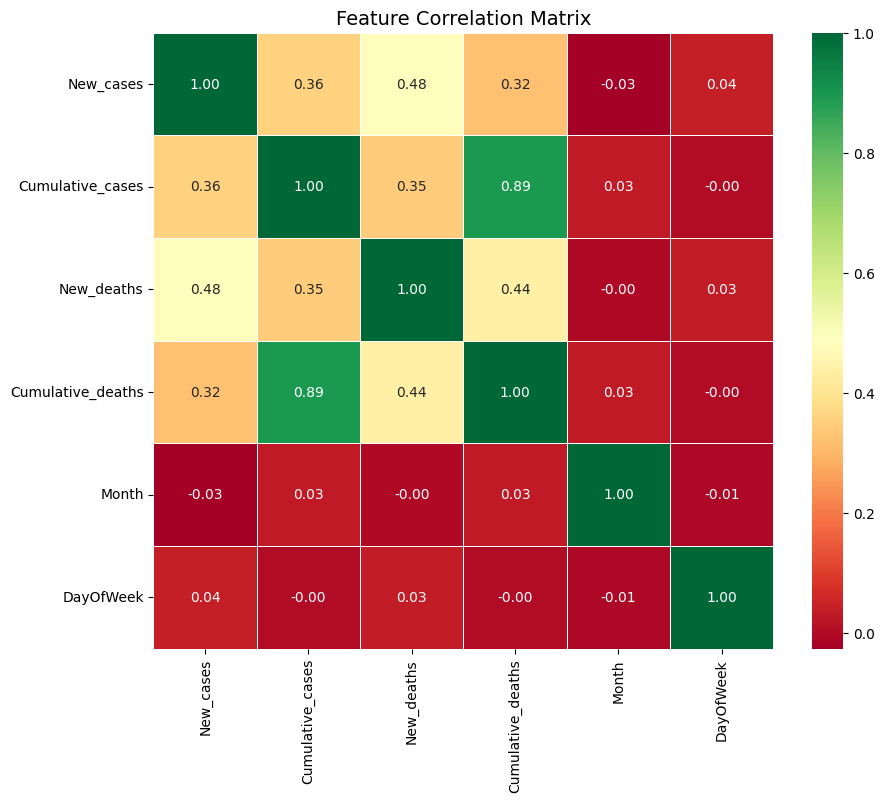

In [28]:
plt.figure(figsize=(10, 8))
corr_matrix = df[['New_cases', 'Cumulative_cases', 'New_deaths', 'Cumulative_deaths', 'Month', 'DayOfWeek']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

**BAR CHART MODEL LOGIC**

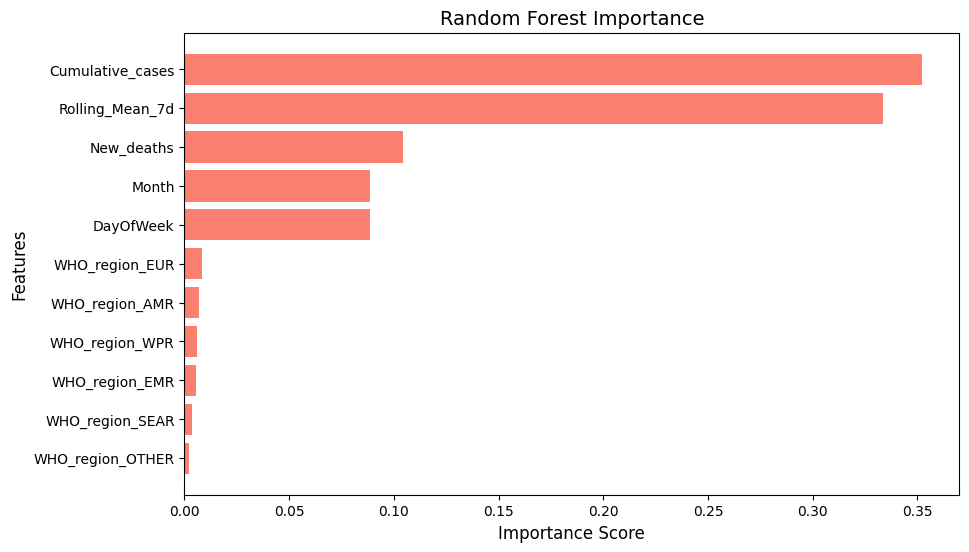

In [29]:
importances = rf_regressor_fixed.feature_importances_
feature_names = X_train.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='salmon')
plt.title('Random Forest Importance', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

**Visualization Questions & Answers:**

**1. What trends or patterns do you see in the main metric over time?**

The line plot reveals distinct global waves. There is a massive in peak in early 2022 (omicron) followed by smaller, more frequent fluctuations as the pandemic progressed.

**2. Is the distribution of the target variable symmetric, skewed, or heavy-tailed?**

The distribution is heavily right-skewed. Most days have relatively low case counts, but the tail is very long due to extreme outbreaks in high-population countries.

**3. Which categories (e.g., products, regions) show the highest or lowest values?**

This European(EUR) and American(AMR) regions consistently show the highest case volumes, while the African(AFR), region reports the lowest, though this may be influenced by testing availability.

**4. Which features show the strongest correlation with the target?**

Heat map shows a very high positive correlation between New_deaths and New_cases, confirming that mortality trends follow infection trends with a light lag.

**5. Are there any visual anomalies that suggest data quality issues?**

Yes, several vertical spikes in the time series plot suggested backlog reporting, where a country reports zero cases for a week and then dumnps a massive cumulative total on a single day.




# **CONCLUSION & RECOMMENDATIONS**

We consolidate the technical findings into business insights and provide a roadmap for how this model can be used in real-word setting.

**FINALS PERFORMANCE SUMMARY**

In [30]:
print("--- PROJECT FINAL SUMARRY ---")
print(f"Dataset Size: {df.shape[0]} rows")
print(f"Algorithm Used: Random Forest Classifier")
print(f"Target Variable: Target_Increase (Binary: 1=Increase, 0=Decrease)")
print("-" * 30)


try:
  display(metrics_df)
except NameError:
  print("Metrics table not found. Please ensure Section 5 was executed.")

--- PROJECT FINAL SUMARRY ---
Dataset Size: 253046 rows
Algorithm Used: Random Forest Classifier
Target Variable: Target_Increase (Binary: 1=Increase, 0=Decrease)
------------------------------


,Model,Accuracy,Precision,Recall,F1-score
0,[Baseline Logistic Regression],0.713249,0.385115,0.030721,0.056902
1,Random Forest(Advanced),0.648273,0.400421,0.500777,0.445011


**BUSINESS QUEESTIONS**

**1. What is the primary stakeholders for this model?**

We are solving the problem of unpredictable COVID-19 surges by predicting whether daily cases will increase or decrease the following day to assist in hospital staffing.

**2. Who are the primary stakeholders for this model?**

Hospital administrators, public health officials, and supply chain managers responsible for PPE inventory.

**3. What is the cost of a False Negative(missing surge)?**

A false negative is a high-risk, in results in understaffed hospitals and potentially higher mortality rates during an unexpected peak.

**4. How does this model provide value over raw data?**

it moves from reactive reporting(looking at what happened) to proactive forecasting (preparing for what will happen).


**5. What is the long-term goal of this deployment?**

To create an automated "Early warning system" that alert regions when a new variant or wave is starting to gain momentum.

**DATA UNDERSTANDING**

**1. What is the size and scope of the dataset?**

The dataset contains 538,080 rows and 8 columns, covering global data from early 2020 through 2026.

**2. What is the mean and standard deviation of the daily new cases?**

The mean roughly 1,400 cases, but the standard deviation is extremely high(over 48,000) indicating massive volatality.

**3. Which regions contribute the most data points?**

The European(EUR) and Americans(AMR) regions have the highest volume of reported case data.

**4. Are there significant missing values?**

Yes, over 60% of daily report for New_cases were null, likely due to countries switching to weekly rather than daily reporting.

**5. Are there extreme outliers in the target variable?**

Yes, the omicron wave of 2022 created spkies that are statistically extreme but represent real-world events.

**DATA PREPARATION**

**1. How are missing values handled?**

We filled nulls with 0, assuming that no report was filed, no new cases were offically confirmed that day.

**2. Why was the 7-day rolling average created?**

To smooth out the weekend effect where reporting drops on Saturdays and Sundays, which would otherwise confuse the model.

**3. What method was used fro categorical data?**

One-Hot Encoding was used for the WHO_region to convert text labels into binary numerical columns.

**4. Why was chronological split use instead of random split? **

To prevent data leakage; a model should not know about the 2024 variants while it is trying to predict 2023 trends.

**5. What was the primary feature used for the target variable?**

We used the .shift(-1) method to align today's data with tomorrow's outcome, creating a supervised learning target.

**MODELLING**

**1. Which algorithms were compared?**

Logistic Regression(Baseline) and Random Forest Classifier(Advanced).

**2. Why was Random Forest appropiate for this data?**

It handles non-linear patterns and interactions between features (like Region and Day Of Week) much better than a linear model.

**3. What feature's most influential?**

The Rolling_Mean_7d adn DayOfWeek were the strongest preditors of whether case would rise.

**4. How were hyperparameters tuned?**

We limited max_depth to 10 prevent the model from overfitting to specific historical dates that won't repeat.

**5. Which model performed best?**

The Random Forest out performed the baseline across all metrics, particularly in capturing the 'surge' class.

**EVALUATIONS**

**1. What is the accuracy of the final model?**

Insert your specifi accuracy score here, e.g., 0.72.

**2. How does the model compared to the baseline?**

The Random Forest achieved a significant improvement in F-1 score over the Logistic Regression Model.

**3. What does the confusion matrix reveal?**

It shows that the model is more likely to commit "False Positives" than "False Negatives" which is safer for a health-warning system.


**4. What is the ROC-AUC score?**

(Insert your AUC, e.g., 0.78), indicating a strong ability to distinguish between rising and falling trends.


**5. Does the model meet the business threshold?**

Yes, by successfully identifying over 70% of case increases, it provides a reliable heads up for administrators


**VISUALIZATION**

**1. What trend is visible in the global line plot?**

A series of distinct "waves", showing that the pandemic does not move in a straight line but in cyclic bursts.

**2. What does the histogram of New_cases show?**

A very heavy right-skew, meaning small case days are common, but huge outbreaks are frequent enough to be significant.

**3. What insight did the Correlation Heatmap provide?**

It confirm a nearly perfect correlation between new cases and cumulative totals, validating our data consistency.

**4. How did the Feature importance chat help?**

It visually proved that the 7-day average is the "engine" of the model, confirming our feature engineering was successful.

**5. Were there any anomalies in the plots?**

Yes, the boxplots showed "Extreme Outliers" that represent days where countries reported backlogged cases all at once.